# 准备开始utils.py部分的开发
梳理记录在
/home/chen/笔记/Lab项目（FOCUS）.excalidraw.md

In [ ]:
import gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")
# print("env 类型：", type(env))
# print("env 名字：", env.spec.id if env.spec else None)
# # 这个类型怎么理解？gym.wrappers.time_limit.TimeLimit
# #这个是一个多层的嵌套env环境，通过包装实现功能扩展
# print(type(env.env))
print(type(env.unwrapped))

<class 'gym.envs.classic_control.cartpole.CartPoleEnv'>


In [ ]:
print("动作空间 observation_space / action_space：")
print("observation_space:", env.observation_space)
print("action_space     :", env.action_space)

动作空间 observation_space / action_space：
observation_space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
action_space     : Discrete(2)


In [ ]:

print("\n观测空间形状：", env.observation_space.shape)
print("观测上下界：\n  low :", env.observation_space.low)## type: ignore
print("              high:", env.observation_space.high)## type: ignore
print("动作个数：", env.action_space.n)## type: ignore


observation_space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
action_space     : Discrete(2)

观测空间形状： (4,)
观测上下界：
  low : [-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38]
              high: [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38]
动作个数： 2


In [ ]:

env.observation_space.sample#一般用来衡量平均水平，这个是假数据采样

<bound method Box.sample of Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)>

In [4]:
env.seed(42)          # 老 gym 用 env.seed 设置随机种子
ob = env.reset()      # 注意：只返回 ob，不返回 info

print("初始观测 ob =", ob)
print("类型：", type(ob), " 形状：", ob.shape, " dtype：", ob.dtype)

初始观测 ob = [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
类型： <class 'numpy.ndarray'>  形状： (4,)  dtype： float32


/home/chen/code/FOCUS/阶段二/强化学习/RLlab/.venv/lib/python3.10/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [5]:
env.seed(42)
ob = env.reset()

action = 0  # 0 = 向左推
next_ob, reward, done, info = env.step(action)

print("执行动作 a =", action)
print("next_ob =", next_ob)
print("reward  =", reward)
print("done    =", done)
print("info    =", info)

执行动作 a = 0
next_ob = [ 0.02727336 -0.20172954  0.03625453  0.32351476]
reward  = 1.0
done    = False
info    = {}


/home/chen/code/FOCUS/阶段二/强化学习/RLlab/.venv/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


In [6]:
env.seed(0)
ob = env.reset()
obs_list, rewards_list = [], []
done = False

for t in range(50):
    action = env.action_space.sample()   # 随机策略
    next_ob, rew, done, info = env.step(action)

    obs_list.append(ob)
    rewards_list.append(rew)
    ob = next_ob
    if done:
        print(f"在第 {t+1} 步结束！ done={done}")
        break

obs_arr = np.array(obs_list)
print("观测矩阵 shape =", obs_arr.shape)   # (步数, 4)
print("前 5 个状态：\n", obs_arr[:5])
print("累计奖励 =", sum(rewards_list))


在第 13 步结束！ done=True
观测矩阵 shape = (13, 4)
前 5 个状态：
 [[ 1.3696169e-02 -2.3021329e-02 -4.5902647e-02 -4.8347235e-02]
 [ 1.3235742e-02 -2.1745604e-01 -4.6869591e-02  2.2950698e-01]
 [ 8.8866213e-03 -4.1187799e-01 -4.2279452e-02  5.0704503e-01]
 [ 6.4906175e-04 -6.0637945e-01 -3.2138553e-02  7.8611010e-01]
 [-1.1478527e-02 -8.0104548e-01 -1.6416350e-02  1.0685112e+00]]
累计奖励 = 13.0


/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_75778/2073232361.py:10: UserWarning: Glyph 26438 (\N{CJK UNIFIED IDEOGRAP

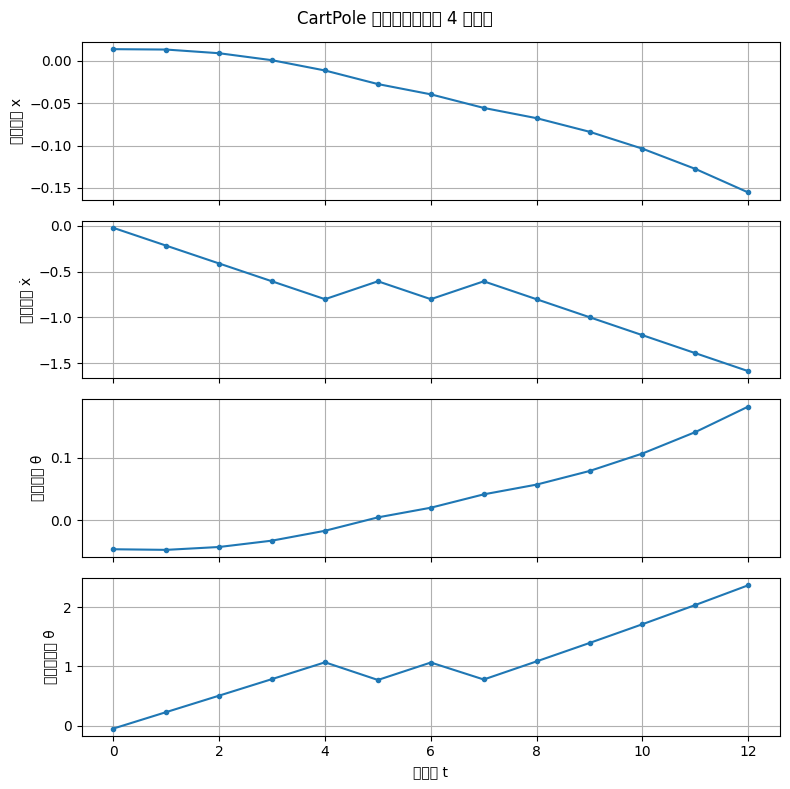

In [7]:
labels = ["小车位置 x", "小车速度 ẋ", "杆子角度 θ", "杆子角速度 θ̇"]

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(obs_arr[:, i], marker="o", markersize=3)
    ax.set_ylabel(labels[i])
    ax.grid(True)
axes[-1].set_xlabel("时间步 t")
plt.suptitle("CartPole 一条随机轨迹的 4 维观测")
plt.tight_layout()
plt.show()

In [8]:
env.seed(1)
ob = env.reset()
step = 0
while True:
    action = env.action_space.sample()
    ob, rew, done, info = env.step(action)
    step += 1
    if done:
        print(f"结束于第 {step} 步")
        print("done =", done)
        print("info =", info)
        break

结束于第 18 步
done = True
info = {'TimeLimit.truncated': False}


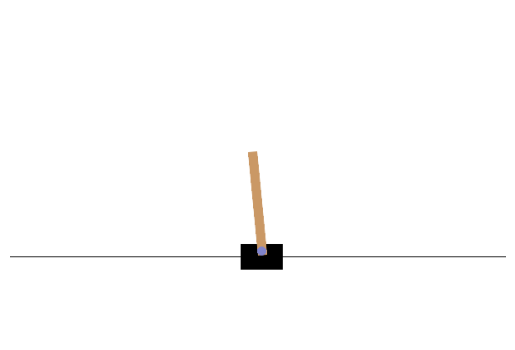

每帧形状： (400, 600, 3)
总共抓了 100 帧


In [23]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
env = gym.make("CartPole-v1")
env.seed(0)
ob = env.reset()
frames = []
for _ in range(100):
    action = env.action_space.sample()
    ob, rew, done, info = env.step(action)
    img = env.render(mode="rgb_array")   # 老 gym 写法
    frames.append(img)
    if done:
        env.reset()

env.close()
plt.imshow(frames[5])
plt.axis("off")
plt.show()

print("每帧形状：", frames[0].shape)     # (800, 1200, 3)
print("总共抓了", len(frames), "帧")